In [1]:
import pathlib
data_dir = pathlib.Path('./flower_photos')
data_dir

WindowsPath('flower_photos')

In [2]:
# 훈련세트 읽기

import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    shuffle=True,
    batch_size=32
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [4]:
# 검증세트 읽기
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(224, 224),
    shuffle=False,
    batch_size=32
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

model1 = Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1), # 360*0.1 = +-36도 회전
    layers.RandomZoom(0.1)      # 10% 범위로 확대축소 적용
])

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

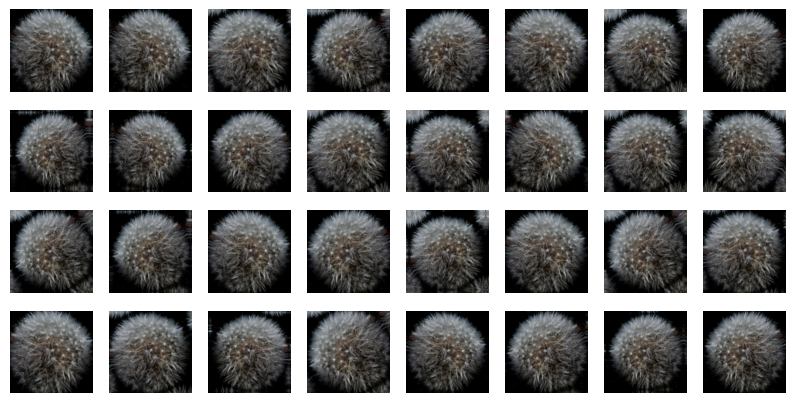

In [19]:
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))

# batch=32개의 이미지를 가져옴
for images, _ in train_ds.take(1):
    for i in range(32):
        changeimg = model1(images)
        plt.subplot(4, 8, i + 1)
        plt.imshow(changeimg[0].numpy().astype("uint8"))
        plt.axis('off')
plt.show()

In [16]:
model1.input_shape

(None, 224, 224, 3)

In [20]:
# EfficientNetV2B0
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

inputs = keras.Input(shape=(224, 224, 3))
# data augmentation
x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomRotation(0.3)(x) # 360*0.1 = +-36도 회전
x = layers.RandomZoom(0.2)(x)      # 10% 범위로 확대축소 적용

base_model = keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",  # ← 사전학습 사용 안 함
    input_tensor=x
)
base_model.trainable = False  # 특징추출기 가중치 업데이트 안함.

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(5, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_1       │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_1   │ (None, 224, 224,  │          0 │ random_flip_1[0]… │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom_1       │ (None, 224, 224,  │          0 │ random_rotation_… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ random_zoom_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_

 Total params: 6,248,533 (23.84 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [22]:
# 모델 체크포인트 콜백 설정 (최고 성능 모델 저장)
model_checkpoint = keras.callbacks.ModelCheckpoint(
    './pkl/20260102_flower_augmentation_best.keras', 
    monitor='val_accuracy',
    save_best_only=True
)

In [25]:
history = model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=5, 
    verbose=2, 
    callbacks=[model_checkpoint]
)

Epoch 1/5
92/92 - 40s - 431ms/step - accuracy: 0.9571 - loss: 0.1251 - val_accuracy: 0.9605 - val_loss: 0.1208
Epoch 2/5
92/92 - 45s - 491ms/step - accuracy: 0.9649 - loss: 0.1048 - val_accuracy: 0.9659 - val_loss: 0.0941
Epoch 3/5
92/92 - 47s - 508ms/step - accuracy: 0.9595 - loss: 0.1121 - val_accuracy: 0.9714 - val_loss: 0.0788
Epoch 4/5
92/92 - 48s - 524ms/step - accuracy: 0.9646 - loss: 0.0980 - val_accuracy: 0.9619 - val_loss: 0.1151
Epoch 5/5
92/92 - 48s - 522ms/step - accuracy: 0.9639 - loss: 0.1024 - val_accuracy: 0.9578 - val_loss: 0.1191


In [26]:
model.save('./pkl/flower.keras')

In [1]:
import cv2
import os

video_path = "./video/flower_panorama1.mp4"
# video2_path = "./video/flower_panorama2.mp4"
output_path = "image"

# frame 폴더생성
os.makedirs(output_path, exist_ok=True)

cap = cv2.VideoCapture(video_path)
frame_idx = 0

interval = 10
image_index = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    filename = os.path.join(output_path, f"frame_{image_index:05d}.jpg")
    if frame_idx % interval == 0:
        cv2.imwrite(filename, frame)
        image_index += 1
    frame_idx += 1

cap.release()

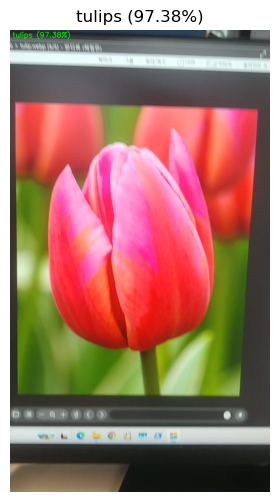

In [12]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

model = load_model('./pkl/flower.keras')
# model = load_model('./pkl/20260102_flower_augmentation_best.keras')
class_names = ["daisy", "dandelion", "roses", "sunflowers", "tulips"]

video_path = "./video/flower_panorama1.mp4"
# video_path = "./video/꽃 동영상.mp4"
cap = cv2.VideoCapture(video_path)
frame_idx = 0

if not cap.isOpened():
    print("비디오 파일 없음")
else:
    interval = 10
    fig, ax = plt.subplots(figsize=(10, 6))

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % interval == 0:
            img = cv2.resize(frame, (224, 224))
            img_arr = np.array(img, dtype=np.float32)
            img_arr = np.expand_dims(img_arr, axis=0)
            pred = model.predict(img_arr, verbose=0)
            pred_class = np.argmax(pred)
            confidence = float(np.max(pred))
            text = f"{class_names[pred_class]} ({confidence:.2%})"

            cv2.putText(frame, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            clear_output(wait=True)
            ax.clear()
            ax.imshow(rgb_frame)
            ax.set_title(text)
            ax.axis('off')
            display(fig)

        frame_idx += 1

    cap.release()
    plt.close()
